# 04 — ERA5-Land climate context
**Purpose:** extract regional daily ERA5-Land temperature, precipitation, snow, radiation, and runoff; derive daily/monthly climate features and seasonal anomalies.  
**Inputs:** GLIMS-derived 15 km context ROI, Earth Engine project ID, and `src/config.py`.  
**Outputs:** cached daily CSV, monthly CSV, and temperature/precipitation/PDD charts.  
**Runtime:** the first 1984–2026 extraction can take 10–30 minutes; later runs reuse the Drive cache.  
**Dependencies:** authenticated Earth Engine account and a registered Cloud project.

## Google Drive setup
The repository is expected at `/content/drive/MyDrive/langtang-glacier-ai`. Satellite and reanalysis pixels remain in Earth Engine; derived tables and charts persist in Drive.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd '/content/drive/MyDrive/langtang-glacier-ai'


Mounted at /content/drive
/content/drive/MyDrive/langtang-glacier-ai


In [2]:
%pip -q install -r requirements.txt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 92.5 MB/s eta 0:00:00


In [3]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import ee
import pandas as pd
from src.climate_features import aggregate_monthly_climate, load_or_extract_daily_climate
from src.config import SETTINGS
from src.gee_utils import DATASET_IDS, build_rois, initialize_earth_engine
from src.utils import ensure_output_directories
from src.visualization import plot_monthly_climate

ensure_output_directories()


Enter the same Google Cloud **project ID** used in earlier notebooks. It is not an API key and no credential is stored by this notebook.

In [4]:
EE_PROJECT = os.environ.get('EE_PROJECT') or input('Earth Engine Cloud project ID: ').strip()
if not EE_PROJECT:
    raise ValueError('An Earth Engine-enabled Google Cloud project ID is required.')
try:
    ee.Initialize(project=EE_PROJECT)
except Exception:
    initialize_earth_engine(project=EE_PROJECT, authenticate=True)
print('Earth Engine initialized with:', EE_PROJECT)


Earth Engine Cloud project ID: my-youtube-api-keys-453716
Earth Engine initialized with: my-youtube-api-keys-453716


## Extract and cache daily regional context
ERA5-Land has an approximately 11.1 km pixel size. Values are spatial means over the 15 km context ROI and represent regional reanalysis context—not conditions at a particular ice face. Set `FORCE_REFRESH=True` only when the Earth Engine source or configuration changed.

In [5]:
rois = build_rois()
FORCE_REFRESH = False
daily_path = SETTINGS.data_processed / 'era5_land_daily_1984_2026.csv'
daily = load_or_extract_daily_climate(
    rois['context_roi'], daily_path, force=FORCE_REFRESH
)
print('Dataset:', DATASET_IDS['era5_land_daily'])
print('Period:', daily['date'].min(), 'to', daily['date'].max())
print('Rows:', len(daily), 'Missing days:', int(daily['missing_data_flag'].sum()))
display(daily.tail())


ERA5-Land 1984: 366 daily records
ERA5-Land 1985: 365 daily records
ERA5-Land 1986: 365 daily records
ERA5-Land 1987: 365 daily records
ERA5-Land 1988: 366 daily records
ERA5-Land 1989: 365 daily records
ERA5-Land 1990: 365 daily records
ERA5-Land 1991: 365 daily records
ERA5-Land 1992: 366 daily records
ERA5-Land 1993: 365 daily records
ERA5-Land 1994: 365 daily records
ERA5-Land 1995: 365 daily records
ERA5-Land 1996: 366 daily records
ERA5-Land 1997: 365 daily records
ERA5-Land 1998: 365 daily records
ERA5-Land 1999: 365 daily records
ERA5-Land 2000: 366 daily records
ERA5-Land 2001: 365 daily records
ERA5-Land 2002: 365 daily records
ERA5-Land 2003: 365 daily records
ERA5-Land 2004: 366 daily records
ERA5-Land 2005: 365 daily records
ERA5-Land 2006: 365 daily records
ERA5-Land 2007: 365 daily records
ERA5-Land 2008: 366 daily records
ERA5-Land 2009: 365 daily records
ERA5-Land 2010: 365 daily records
ERA5-Land 2011: 365 daily records
ERA5-Land 2012: 366 daily records
ERA5-Land 2013

,date,precip_mm,runoff_mm,snow_depth_m,snowfall_mm_we,solar_radiation_mj_m2,system:time_start,temp_max_c,temp_mean_c,temp_min_c,observation_count,missing_data_flag,precip_3d_mm,precip_7d_mm,precip_30d_mm,positive_degree_days,freeze_thaw_cycle,month_day,temp_anomaly_c
15573,2026-08-21,23.836917,18.244449,2.899932,0.047477,15.910645,1787270400000,10.629780,7.828498,6.009093,1,False,44.974274,116.617026,453.043027,7.828498,0,08-21,1.053523
15574,2026-08-22,11.011670,11.301474,2.900165,0.076353,12.703495,1787356800000,10.408121,7.574592,5.772061,1,False,46.488471,111.669489,449.691679,7.574592,0,08-22,0.851590
15575,2026-08-23,9.248913,10.208520,2.899952,0.015544,17.820809,1787443200000,11.382048,8.080139,5.764920,1,False,44.097501,91.730023,446.353229,8.080139,0,08-23,1.464507
15576,2026-08-24,4.971380,8.175634,2.899918,0.016412,18.439526,1787529600000,10.596578,8.027738,5.983113,1,False,25.231964,81.086888,442.922641,8.027738,0,08-24,1.327697
15577,2026-08-25,6.575623,8.402011,2.899911,0.019160,18.872568,1787616000000,10.923846,8.023373,5.675749,1,False,20.795916,76.781860,439.072135,8.023373,0,08-25,1.399275


In [6]:
monthly = aggregate_monthly_climate(daily)
monthly_path = SETTINGS.output_tables / 'era5_land_monthly_climate.csv'
monthly.to_csv(monthly_path, index=False)
display(monthly.tail(18))
print('Saved:', monthly_path)


,date,temp_mean_c,temp_max_c,temp_min_c,temp_anomaly_c,precip_month_mm,precip_1d_max_mm,precip_3d_max_mm,precip_7d_max_mm,precip_30d_max_mm,...,valid_area_fraction,period_completeness,is_complete_period,quality_status,quality_reason,expected_days,missing_data_flag,month,precip_anomaly_z,pdd_anomaly_z
494,2025-03-01,-5.927125,4.124642,-17.579670,0.558191,47.552459,9.580936,29.869582,35.305724,89.935600,...,None,1.000000,True,GOOD,coverage and completeness requirements passed,31,False,3,-0.597698,-0.263525
495,2025-04-01,-1.665825,5.789748,-11.805456,1.275408,79.250688,10.628366,22.425798,33.170289,79.250688,...,None,1.000000,True,GOOD,coverage and completeness requirements passed,30,False,4,0.451284,-0.082854
496,2025-05-01,2.674047,10.148621,-8.668634,1.416435,160.511544,19.220914,30.404806,54.660077,157.352141,...,None,1.000000,True,GOOD,coverage and completeness requirements passed,31,False,5,0.527653,1.619251
497,2025-06-01,5.938024,13.088634,-4.843439,0.385120,381.251352,27.030255,72.423812,141.561713,381.251352,...,None,1.000000,True,GOOD,coverage and completeness requirements passed,30,False,6,1.454152,0.593451
498,2025-07-01,7.955694,12.697812,3.997629,0.768242,411.318060,32.238669,66.264496,118.606355,452.870285,...,None,1.000000,True,GOOD,coverage and completeness requirements passed,31,False,7,-0.893096,1.772984
499,2025-08-01,7.566875,12.436501,4.462229,0.609156,424.106011,32.478017,63.405191,118.513899,433.443359,...,None,1.000000,True,GOOD,coverage and completeness requirements passed,31,False,8,0.176509,1.551711
500,2025-09-01,6.263319,11.006812,2.027688,1.233182,259.508014,14.763077,41.668564,107.639790,412.511643,...,None,1.000000,True,GOOD,coverage and completeness requirements passed,30,False,9,0.388635,1.933348
501,2025-10-01,0.370723,6.678553,-10.057018,0.361146,236.403465,70.022087,112.228241,161.687011,365.980025,...,None,1.000000,True,GOOD,coverage and completeness requirements passed,31,False,10,2.925317,-0.289542
502,2025-11-01,-4.169219,2.976036,-12.132678,-0.173294,25.125000,9.449699,64.904056,99.680438,203.820176,...,None,1.000000,True,GOOD,coverage and completeness requirements passed,30,False,11,-0.244817,-0.074647
503,2025-12-01,-5.051657,3.333933,-14.831047,1.687053,1.628558,0.520470,0.672726,0.843051,15.689776,...,None,1.000000,True,GOOD,coverage and completeness requirements passed,31,False,12,-1.189120,-0.310535


Saved: /content/drive/MyDrive/langtang-glacier-ai/outputs/tables/era5_land_monthly_climate.csv


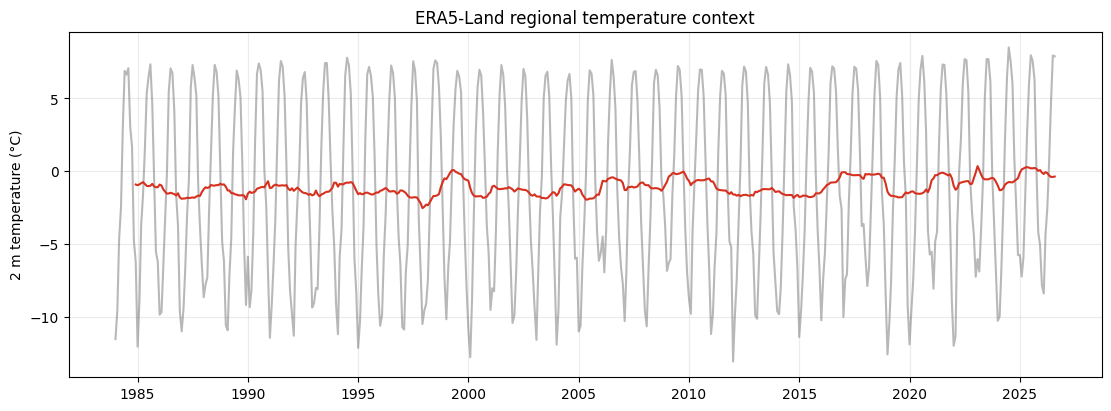

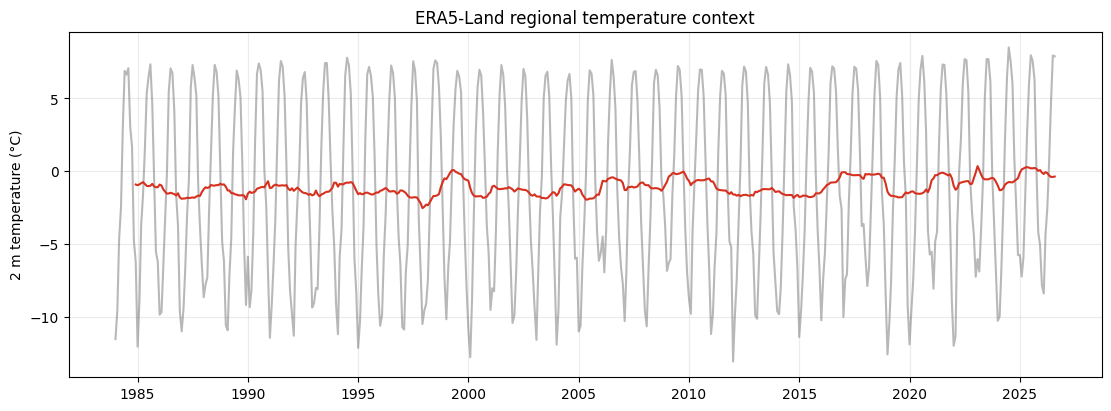

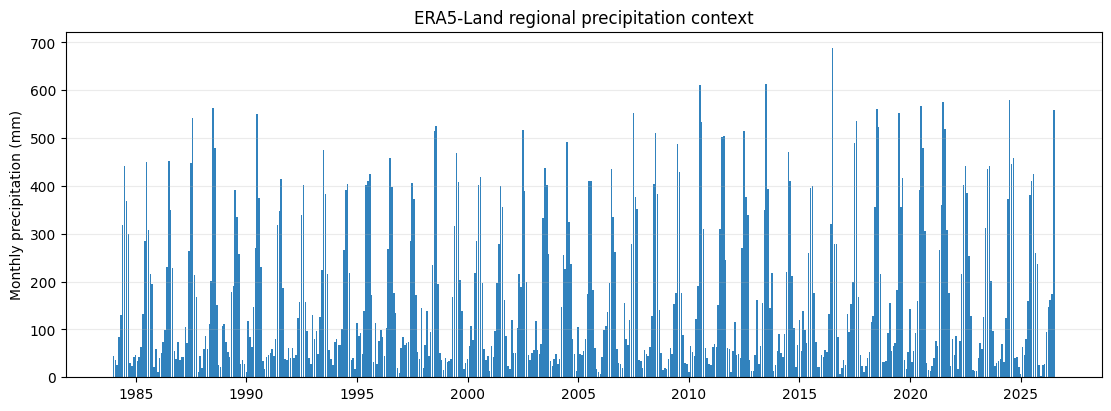

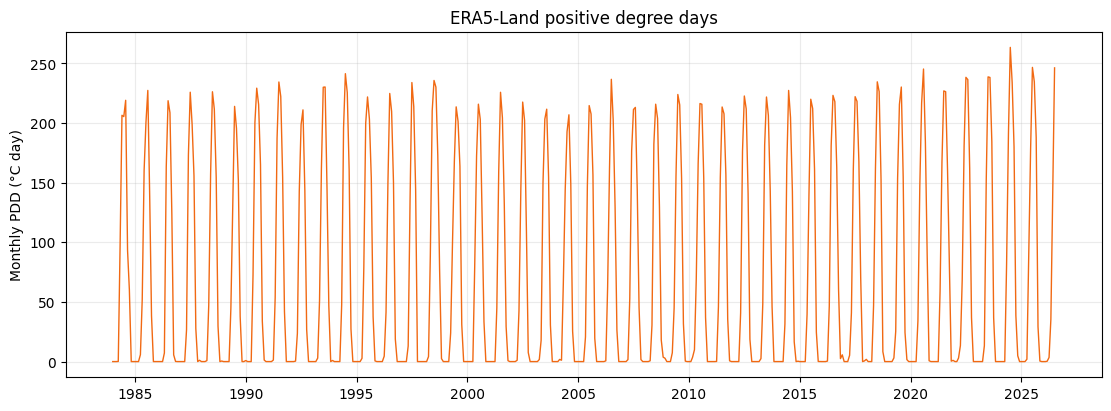

In [7]:
figures = plot_monthly_climate(monthly, SETTINGS.output_charts)
figures[0]


## Quality and interpretation checkpoint
Review `observation_count` and `missing_data_flag` before using a month. The most recent ERA5-Land date normally lags real time. Precipitation/snowfall/runoff are model grid-cell water-depth equivalents; negative accumulation artifacts are clipped to zero and documented. Temperature anomaly uses day-of-year climatology, while monthly precipitation and PDD anomalies compare like calendar months over 1984–2025. These data cannot resolve local slope, aspect, shading, or glacier-face microclimate.